In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile

In [2]:
sample_rate = 16_000
duration = 1.0
freq = 440

t = np.arange(0,duration,1/sample_rate)
audio = np.sin(2*np.pi*freq*t)

print(f'Samples: {len(audio)}')
print(f'Duration: {len(audio)/sample_rate:.2f} seconds')

Samples: 16000
Duration: 1.00 seconds


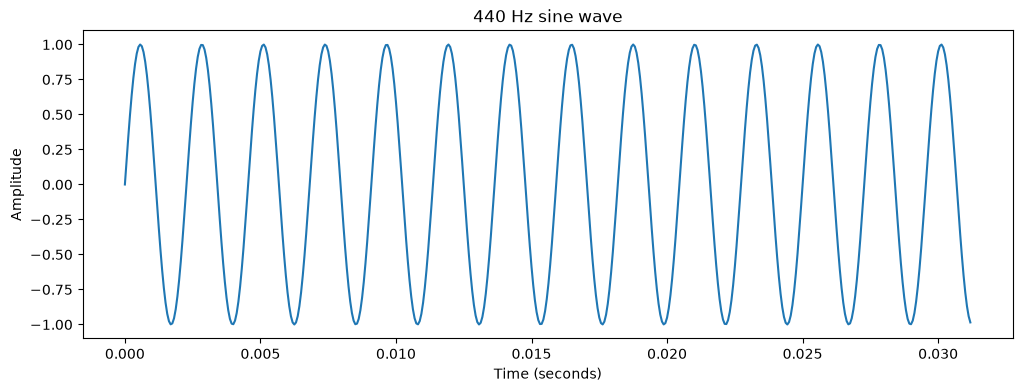

In [3]:
plt.figure(figsize=(12, 4))

plt.plot(t[:500], audio[:500])

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("440 Hz sine wave")

plt.show()

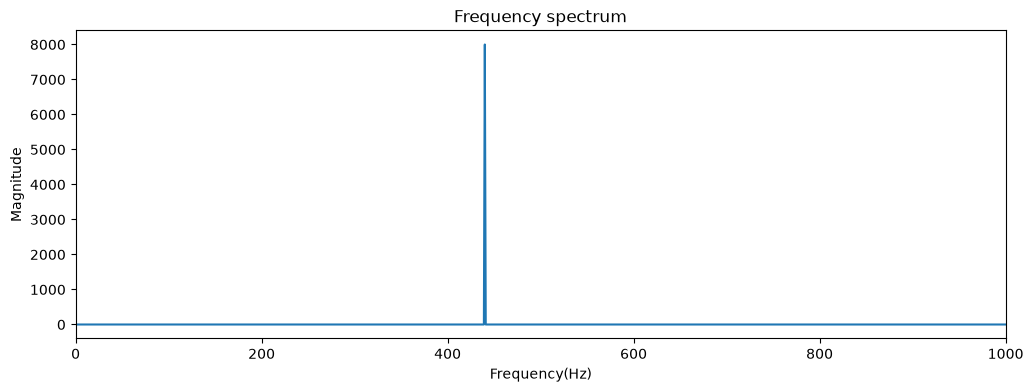

In [5]:
fft = np.fft.rfft(audio)
freqs = np.fft.rfftfreq(len(audio), 1/sample_rate)
magnitude = np.abs(fft)

plt.figure(figsize=(12,4))
plt.plot(freqs,magnitude)

plt.xlim(0,1000)
plt.xlabel('Frequency(Hz)')
plt.ylabel('Magnitude')
plt.title('Frequency spectrum')

plt.show()

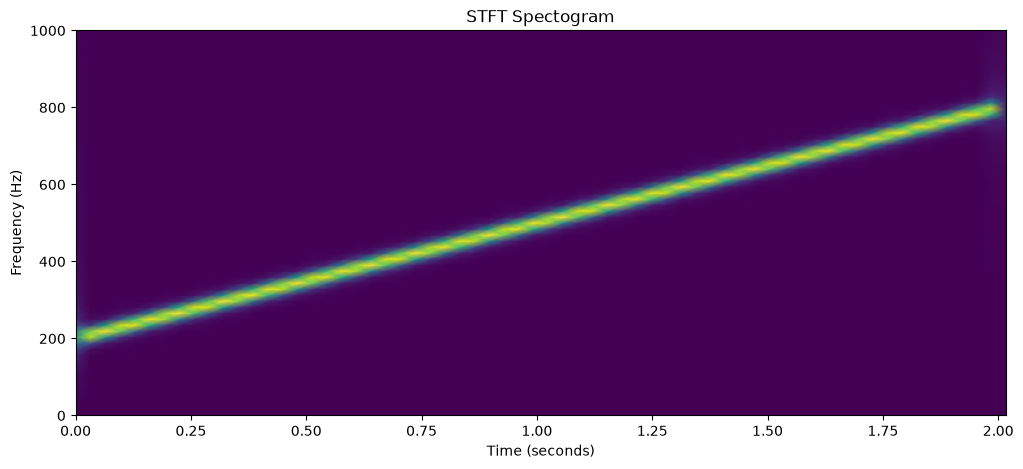

In [9]:
t2 = np.linspace(0, 2, 2*sample_rate, endpoint = False)
audio2 = signal.chirp(t2, f0=200, f1=800, t1=2, method='linear')

freqs, times, Zxx = signal.stft(audio2, fs=sample_rate,nperseg=1024,noverlap=512)

magnitude = np.abs(Zxx)

plt.figure(figsize=(12,5))
plt.pcolormesh(times, freqs, magnitude, shading='gouraud')

plt.ylim(0, 1000)
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency (Hz)')
plt.title('STFT Spectogram')

plt.show()

In [14]:
sample_rate, piano = wavfile.read('C:/Users/Deep/Desktop/Deep/Piano2MIDI/piano2midi/data/raw/pianoloop.wav')
print('Sample rate:',sample_rate)
print('Shape:',piano.shape)
print('Duration:',len(piano)/sample_rate,'seconds')

Sample rate: 44100
Shape: (310272,)
Duration: 7.035646258503402 seconds


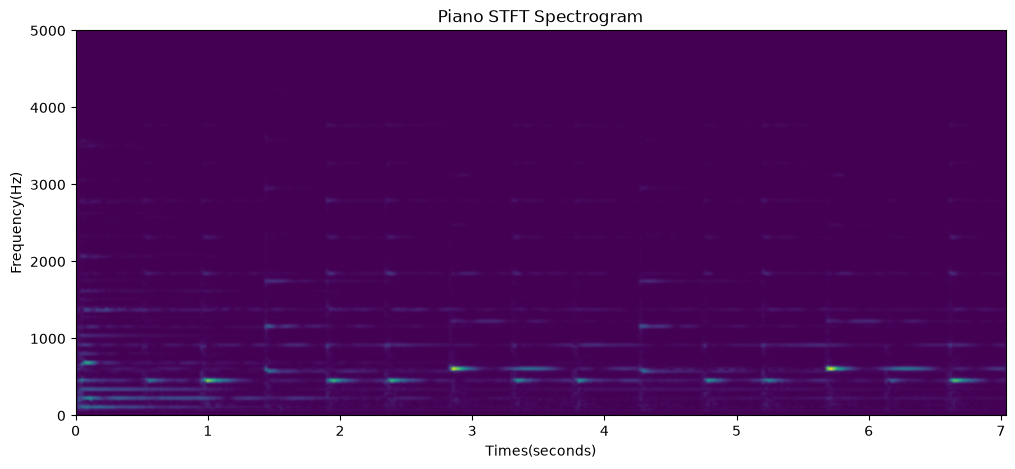

In [17]:
piano = piano.astype(float)
freqs, times, Zxx = signal.stft(piano, fs=sample_rate,nperseg=2048,noverlap=1024)
magnitude = np.abs(Zxx)

plt.figure(figsize=(12,5))
plt.pcolormesh(times, freqs, magnitude, shading='gouraud')

plt.ylim(0,5000)
plt.xlabel('Times(seconds)')
plt.ylabel('Frequency(Hz)')
plt.title('Piano STFT Spectrogram')
plt.show()

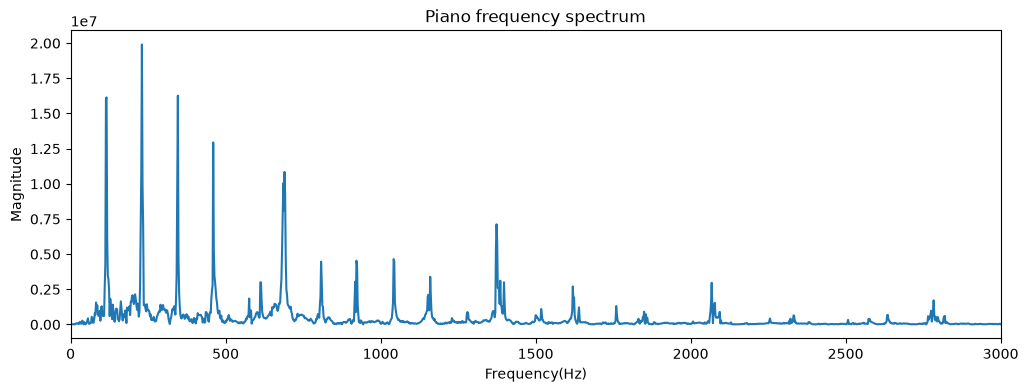

In [19]:
segment = piano[:int(0.5*sample_rate)]

fft = np.fft.rfft(segment)
freqs = np.fft.rfftfreq(len(segment),1/sample_rate)
magnitude = np.abs(fft)

plt.figure(figsize=(12,4))
plt.plot(freqs, magnitude)

plt.xlim(0,3000)
plt.xlabel('Frequency(Hz)')
plt.ylabel('Magnitude')
plt.title('Piano frequency spectrum')
plt.show()

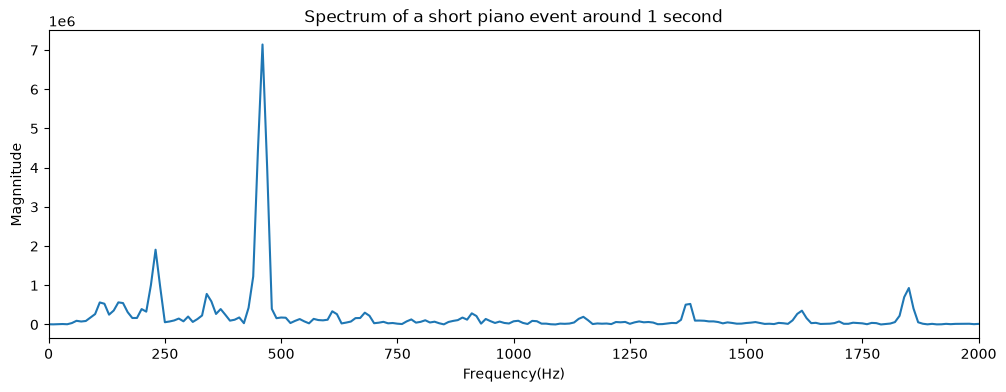

In [21]:
center_time = 1.0
window_duration = 0.1
start = int((center_time-window_duration/2)*sample_rate)
end = int((center_time + window_duration/2)*sample_rate)

note = piano[start:end]

window = np.hanning(len(note))
note_windowed = note*window

fft = np.fft.rfft(note_windowed)
freqs = np.fft.rfftfreq(len(note_windowed),1/sample_rate)
magnitude = np.abs(fft)

plt.figure(figsize=(12,4))
plt.plot(freqs, magnitude)

plt.xlim(0,2000)
plt.xlabel('Frequency(Hz)')
plt.ylabel('Magnnitude')
plt.title('Spectrum of a short piano event around 1 second')
plt.show()